In [1]:
import torch
import os
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ortho_group

%run TwoLayerNN.ipynb

In [599]:
# MNIST examples

from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# 1. Define a transform to convert PIL → tensor (we only need the raw pixels)
transform = transforms.ToTensor()

# 2. Download / load the train split of MNIST
mnist_train = datasets.MNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)

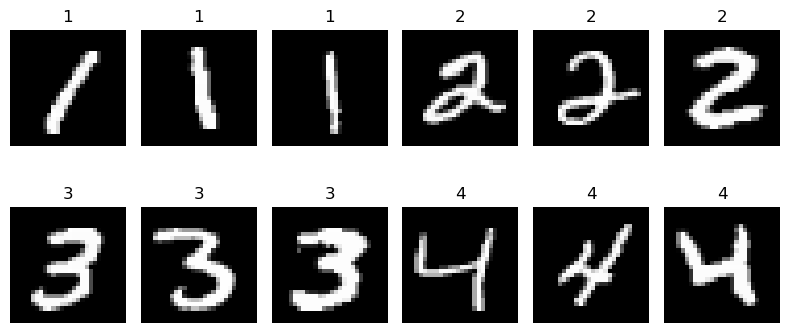

In [1510]:
# 3. Grab the images & labels
images, labels = zip(*[(mnist_train[i][0], mnist_train[i][1]) for i in [3,6,8,5,16,25,7,12,27,2,9,20]])

#[3,6,8]
#[5，16,25]
#[7,12,27]
#[2,9,20]

fig, axes = plt.subplots(2, 6, figsize=(8, 4))
axes = axes.flatten()

for img, lbl, ax in zip(images, labels, axes):
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(int(lbl))
    ax.axis('off')

plt.tight_layout()
plt.savefig('MNIST.eps', dpi=300)
plt.show()

In [1652]:
# add colors to the image
from torchvision import transforms
to_pil   = transforms.ToPILImage()
to_tensor = transforms.ToTensor()

odd_color = torch.tensor([58, 183, 225])/255
even_color = torch.tensor([28, 44, 188])/255
small_color = torch.tensor([43, 255, 68])/255
large_color = torch.tensor([43, 72, 68])/255


x = np.arange(28)
y = np.arange(28)
X, Y = np.meshgrid(x, y, indexing='xy')  
coords = np.stack([X.ravel(), Y.ravel()], axis=1)
coords_left  = coords[coords[:,1] <  28//2]
coords_right = coords[coords[:,1] >= 28//2]

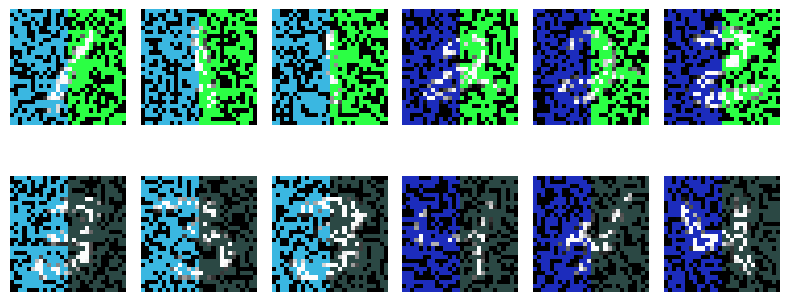

In [1670]:
num_pixel = 230

fig, axes = plt.subplots(2, 6, figsize=(8, 4))
axes = axes.flatten()

for img, lbl, ax in zip(images, labels, axes):

    left_idx = np.random.choice(len(coords_left), num_pixel, replace = False)
    right_idx = np.random.choice(len(coords_right), num_pixel, replace = False)
    
    pil_gray = to_pil(img)
    pil_rgb = pil_gray.convert('RGB')    
    rgb = to_tensor(pil_rgb)         
    img_rgbg = rgb.permute(1, 2, 0)  
    rgb_img = img_rgbg.cpu().numpy() 

    rows_l, cols_l = coords_left[left_idx].T
    rows_r, cols_r = coords_right[right_idx].T

    if (lbl == 1) or (lbl == 3):
        rgb_img[rows_l, cols_l, :] = odd_color
    else:
        rgb_img[rows_l, cols_l, :] = even_color
        
    if (lbl == 1) or (lbl == 2):
        rgb_img[rows_r, cols_r, :] = small_color
    else:
        rgb_img[rows_r, cols_r, :] = large_color

    ax.imshow(rgb_img)
    ax.axis('off')

plt.tight_layout()
plt.savefig('MNIST.eps', dpi=300)
plt.show()

Epoch [1/4000], Loss: 1.0000
Epoch [1000/4000], Loss: 0.9647
Epoch [2000/4000], Loss: 0.0628
Epoch [3000/4000], Loss: 0.0489
Epoch [4000/4000], Loss: 0.0487


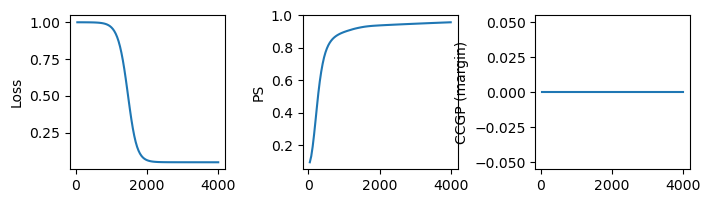

0.9580512642860413


In [70]:
# whitened inputs

import itertools

epsilon = 1e-3
hidden_size = 400
output_size = 2
input_size =  2**output_size
lr = 0.01
wd = 0.1

num_epochs = 4000


X_train0 = torch.eye(2**output_size, dtype = torch.float32)
X_train = torch.cat((X_train0, torch.zeros(X_train0.size(0), input_size - X_train0.size(1))), dim = 1)

y_train = 2*(torch.tensor(list(itertools.product([0, 1], repeat = output_size)))-1/2)


epoch_num, loss1_list, ps1_list, ccgp1_list, pr1_list, pc1_list, s1_list, h1_list = train_twolayerNN(X_train, y_train, input_size, hidden_size, output_size, epsilon, epsilon, lr, num_epochs, 1,wd,0)
ThreePlot(epoch_num, loss1_list, ps1_list, ccgp1_list)
print(ps1_list[-1])

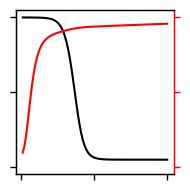

In [96]:
# loss/PS vs. time

# Create figure and first axes
fig, ax1 = plt.subplots(figsize=(2, 2))

# Plot on the left y‐axis
ax1.plot(epoch_num, loss1_list, 'k-')
ax1.set_xlabel('')
ax1.set_ylabel('')

ax1.set_xticks([0, 2000, 4000])
ax1.set_xticklabels(['','',''])
ax1.set_yticks([0, 0.5, 1])
ax1.set_yticklabels(['','',''])
ax1.tick_params(axis='x', width=1, length=4)
ax1.tick_params(axis='y', width=1, length=4)
ax1.set(ylim=(-0.05, 1.05))


for spine in ['left','bottom', 'top']:
    ax1.spines[spine].set_linewidth(1)

# Create second axes that shares the same x‐axis
ax2 = ax1.twinx()
# Plot on the right y‐axis
ax2.plot(epoch_num,  ps1_list, 'r-')
ax2.set_ylabel('')
ax2.tick_params(axis='y', colors='r',width=1, length=4)
ax2.set_yticks([0, 0.5, 1])
ax2.set_yticklabels(['','',''])
ax2.spines['right'].set_color('r')
ax2.spines['right'].set_linewidth(1)
ax2.set(ylim=(-0.05, 1.05))



fig.align_ylabels([ax1, ax2])
# Save the figure to disk
plt.savefig('Loss_epochs.eps', dpi=300)
plt.tight_layout()
plt.show()

In [1698]:
# whitened inputs (arbitrary dimension)

epsilon = 1e-3
hidden_size = 400
num_repeat = 10

dy = [2, 3, 4, 5, 6, 7, 8]
wd_l = [0.01, 0.01, 0.01, 0.01, 0.01, 0.005, 0.003]
lr_l = [0.02, 0.02, 0.02, 0.03, 0.03, 0.07, 0.09]
epochs_list = [40000, 40000, 80000, 80000, 80000, 180000, 200000]
ck = np.zeros((len(dy), num_repeat))
coeff = np.zeros((len(dy), num_repeat))

for i in range(len(dy)):
    output_size = dy[i]
    input_size =  2**output_size
    lr = lr_l[i]
    wd = wd_l[i]
    
    num_epochs = epochs_list[i]
    
    X_train0 = torch.eye(2**output_size, dtype = torch.float32)
    X_train = torch.cat((X_train0, torch.zeros(X_train0.size(0), input_size - X_train0.size(1))), dim = 1)
    y_train = 2*(torch.tensor(list(itertools.product([0, 1], repeat = output_size)))-1/2)
    
    for j in range(num_repeat):
        epoch_num, loss1_list, ps1_list, ccgp1_list, pr1_list, pc1_list, s1_list, h1_list = train_twolayerNN(X_train, y_train, input_size, hidden_size, output_size, epsilon, epsilon, lr, num_epochs, 0,wd,0)
        #ThreePlot(epoch_num, loss1_list, ps1_list, ccgp1_list)
        #print(ps1_list[-1])
        
        
        Ch = np.matmul(h1_list[-1].T, h1_list[-1]) 
        Ch0 = Ch/np.sqrt((input_size+1)/input_size/(input_size + 2)) 
        Cy = np.matmul(y_train.numpy(), y_train.numpy().T) + output_size
        #ck[i, j] = np.trace(np.matmul(Ch0, Cy))/np.linalg.norm(Ch0)/np.linalg.norm(Cy)
        ck[i, j] = np.trace(np.matmul(Ch0, Cy))/np.trace(Ch0)/np.trace(Cy)
        coeff[i, j] = np.linalg.norm(Ch0)/np.linalg.norm(Cy)
        print(ck[i, j], coeff[i, j], np.mean(loss1_list[-5:]))

0.37474794161877073 0.9815029676915196 0.0004823987605050206
0.37511072999548134 0.9862482641366969 0.00048354286118410526
0.37493555232785364 0.9831010311750779 0.00048263046774081885
0.37490583797967675 0.982974342338169 0.0004825690004508942
0.37485695197572694 0.9835765125138588 0.00048306143726222216
0.3747995326952367 0.9815726518566501 0.00048220582539215684
0.3748761782509893 0.983047014756751 0.00048274865839630364
0.37486279578429216 0.9846020737194819 0.00048341702786274253
0.3749234596887169 0.9815583003967823 0.000481816875981167
0.37480720714024374 0.983186354043029 0.00048297736793756485
0.34085100285218894 1.0278299820150498 0.0020387234166264535
0.34254327760491093 1.0455268026369877 0.002048342768102884
0.3422466916452455 1.0423583054138266 0.0020465969108045103
0.34200715645404506 1.0396779131687413 0.002045161696150899
0.34225733152083687 1.0426202374140288 0.002046883851289749
0.34173643783707336 1.0371131137445835 0.002043840056285262
0.3415010850069056 1.03482231

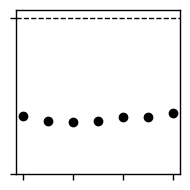

In [1700]:
# plot
filename = f'Alignment.npz'
folder_path = os.path.join(os.getcwd(), filename)
np.savez(folder_path, ck = ck, coeff = coeff)


fig, ax = plt.subplots(1, 1, figsize=(2, 2))

ax.errorbar(dy, np.mean(ck, axis = 1), yerr = np.std(ck, axis = 1),
    fmt='o',                     # square markers
    ecolor='red',
    elinewidth = 1.5, capsize = 3, markeredgecolor = 'k',markerfacecolor = 'k')
#ax.scatter(dy, ck[:,0], color = 'k')
ax.axhline(y = 1, color='k', linestyle='--', linewidth=1)
ax.set_xticks([2, 4, 6, 8])
ax.set_xticklabels(['','','',''])
ax.set_yticks([0, 1])
ax.set_yticklabels(['',''])
ax.tick_params(axis='x', width=1, length=4)
ax.tick_params(axis='y', width=1, length=4)
ax.set(ylim=(0, 1.05))


for spine in ['left','bottom', 'top', 'right']:
    ax.spines[spine].set_linewidth(1)

#plt.legend()
#plt.savefig('TheoryvsSim.eps', dpi=300)
plt.tight_layout()
plt.show()

In [186]:
np.std(ck, axis = 1)

array([1.53653235e-05, 2.18772033e-04, 4.89707994e-04, 2.59146586e-04,
       6.16651283e-04, 5.54399351e-04, 4.28700834e-04])

In [1690]:
# PS vs Cxy for commutative perturbation (ReLU)

eps = 1e-3
input_size =  10
hidden_size = 700
output_size = 3
lr = 0.03
wd = 0.02

num_repeat = 50
r11 = 0

xy_align_tot = np.zeros(( 9*num_repeat, ))
ps_tot = np.zeros(( 9*num_repeat, ))
ck_tot = np.zeros(( 9*num_repeat, ))

epsilon = eps
filename = f'Yortho_ReLU_{r11}_TwoLayer_{wd}_Sysinitial_{epsilon}_inputsize_{input_size}_outputsize_{output_size}_lr_{lr}_numlist.npz'
folder_path = os.path.join(os.getcwd(), filename)
a = np.load(folder_path)
num_list = a['num_list']

y_train = 2*(torch.tensor(list(itertools.product([0, 1], repeat = output_size)))-1/2)
xy_align = np.zeros((num_repeat, len(num_list)-1, 2))
max_ck = np.zeros((num_repeat, len(num_list)-1, 2))
ps_stats = np.zeros((num_repeat, len(num_list)-1))
perf_stats = np.zeros((num_repeat, len(num_list)-1))

iden = torch.eye(2**output_size, dtype = torch.float32)
y_train = 2*(torch.tensor(list(itertools.product([0, 1], repeat = output_size)))-1/2)
cy = np.matmul(y_train, y_train.T)/(2**output_size)
cyo = iden - cy - 1/(2**output_size)
Uyo, S, Vyot = np.linalg.svd(cyo)
U = np.concatenate((np.ones((1,2**output_size))/np.sqrt(2**output_size), y_train.numpy().T/np.sqrt(2**output_size), Vyot[:2**output_size - output_size-1,:]), axis=0)


for i in range(len(num_list)-1):
    for j in range(num_list[i]):
        filename = f'Two-Layer Scan\Yortho_ReLU_{r11}_cvalue_{i+1}_TwoLayer_{wd}_Sysinitial_{epsilon}_inputsize_{input_size}_outputsize_{output_size}_lr_{lr}_repeat_{j}.npz'
        folder_path = os.path.join(os.getcwd(), filename)
        data = np.load(folder_path)
        X_train = data['X_train']
        X_train1 =  np.concatenate((X_train, np.ones((X_train.shape[0], 1))), axis = 1)
        loss1_list = data['loss1_list']
        ps1_list = data['ps1_list']
    
        # compute histogram
        ps_stats[j, i] = np.mean(ps1_list[-5:])
        perf_stats[j, i] = np.mean(loss1_list[-5:])

        # compute alignment
        cx = np.matmul(X_train, X_train.T)
        cy = np.matmul(y_train, y_train.T)

        ck = np.diag(U @ (cx @ U.T))
        
        xy_align[j, i, 0] = np.trace(np.matmul(cx, cy))/np.trace(cx)/np.trace(cy)*output_size
        #xy_align[j, i, 0] = np.trace(np.matmul(cx, cy))/np.linalg.norm(cx)/np.linalg.norm(cy)
        xy_align[j, i, 1] = np.trace(cx)**2/np.linalg.norm(cx)**2
        max_ck[j, i, 0] = np.max(ck[output_size:])
        max_ck[j, i, 1] = np.max(ck[1:output_size])

idx = (perf_stats[:,:] <= 0.1)
num_element = np.count_nonzero(idx)
xy_align_tot[:num_element] = xy_align[idx, 0].flatten()
ck_tot[:num_element] = np.divide(max_ck[idx, 0].flatten(), max_ck[idx, 1].flatten())
ps_tot[:num_element] = ps_stats[idx].flatten()

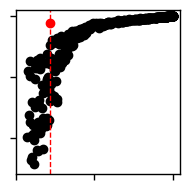

In [1694]:
ch0 = np.trace(np.matmul(np.eye(y_train.shape[0]), cy))/np.trace(np.eye(y_train.shape[0]))/np.trace(cy)*output_size
#ch0 = np.trace(np.matmul(np.eye(y_train.shape[0]), cy))/np.linalg.norm(cy)/np.trace(np.eye(y_train.shape[0]))
#print(ch0)

fig, ax = plt.subplots(1, 1, figsize=(2, 2))

ax.scatter(xy_align_tot, ps_tot, color = 'k')
ax.scatter([ch0], [0.94], color = 'r')
ax.axvline(x=ch0, color='r', linestyle='--', linewidth=1)
ax.set_xticks([0, 0.5, 1])
ax.set_xticklabels(['','',''])
ax.set_yticks([0, 0.5, 1])
ax.set_yticklabels(['','',''])
ax.tick_params(axis='x', width=1, length=4)
ax.tick_params(axis='y', width=1, length=4)
ax.set(ylim=(-0.3, 1.05))


for spine in ['left','bottom', 'top', 'right']:
    ax.spines[spine].set_linewidth(1)


#plt.legend()
plt.savefig('PSvsCxy.eps', dpi=300)
plt.tight_layout()
plt.show()

In [4]:
# Modularity analysis

epsilon = 1e-5
input_size =  4
hidden_size = 200
output_size = 2
lr = 0.01
wd = 0.03
rho = 0
noise = 0

num_epochs = 50000

m = np.eye(input_size)
X_train0 = torch.tensor([[1, rho, rho, rho], [rho, 1, rho, rho], [rho, rho, 1, rho], [rho, rho, rho, 1]],dtype = torch.float32)
X_train1 = torch.cat((X_train0, torch.zeros(X_train0.size(0), input_size - X_train0.size(1))), dim = 1)
X_train2 = torch.mm(torch.from_numpy(m.astype(np.float32)), X_train1.T).T
X_train = torch.cat((X_train2, torch.ones((X_train2.size(0), 1), dtype = torch.float32)), axis = 1)

y_train = torch.tensor([[1,1],[1,-1],[-1,1],[-1,-1]],dtype = torch.float32)

epoch_num, loss1_list, ps1_list, ccgp1_list, pr1_list, pc1_list, s1_list, h1_list, w1_list1, w2_list1 = train_twolayerNN_MuPW12(X_train, y_train, input_size+1, hidden_size, output_size, epsilon*np.sqrt(hidden_size/X_train0.size(1)), epsilon, lr, num_epochs, 1,wd,noise)
#ThreePlot(epoch_num, loss1_list, ps1_list, ccgp1_list)
#print(ps1_list[-1])
#PCAplot(pc1_list, s1_list[-1])

#print(np.matmul(h1_list[-1].T, h1_list[-1]))
#print(np.matmul(y_train, y_train.T))

Epoch [1/50000], Loss: 1.0000
Epoch [5555/50000], Loss: 0.0044
Epoch [11110/50000], Loss: 0.0043
Epoch [16665/50000], Loss: 0.0043
Epoch [22220/50000], Loss: 0.0043
Epoch [27775/50000], Loss: 0.0043
Epoch [33330/50000], Loss: 0.0043
Epoch [38885/50000], Loss: 0.0043
Epoch [44440/50000], Loss: 0.0043
Epoch [49995/50000], Loss: 0.0043


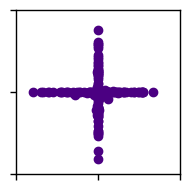

In [10]:
w2 = w2_list1[-1]

fig, ax = plt.subplots(1, 1, figsize=(2, 2))

ax.scatter(w2[0,:], w2[1,:], color = 'indigo')
ax.set_xticks([-0.5, 0, 0.5])
ax.set_xticklabels(['','',''])
ax.set_yticks([-0.5, 0, 0.5])
ax.set_yticklabels(['','',''])
ax.tick_params(axis='x', width=1, length=4)
ax.tick_params(axis='y', width=1, length=4)

for spine in ['left','bottom', 'top', 'right']:
    ax.spines[spine].set_linewidth(1)

plt.gca().set_aspect('equal')
plt.savefig('W2_cluster.eps', dpi=300)
plt.tight_layout()
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


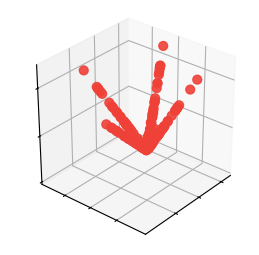

In [30]:
# Example: Create a 400x400 matrix (each row is a data point)
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D  

neu_activity = h1_list[-1]
row_norms = np.linalg.norm(neu_activity, axis=1, keepdims=True)

idx = row_norms > 0.001
neu_normactivity = neu_activity[idx.flatten(),:]

pca = PCA(n_components=3)
X3 = pca.fit_transform(neu_normactivity)    # shape: (150, 3)

# 2) Plot
fig = plt.figure(figsize=(3,3))
ax  = fig.add_subplot(111, projection='3d')

ax.scatter(X3[:,0], X3[:,1], X3[:,2], s=40, alpha=0.9, color = (239/255, 65/255, 56/255))

# custom (empty) ticks
ax.set_xticks([-0.2, 0, 0.2])   
ax.set_xticklabels(['','',''])
ax.set_yticks([-0.2, 0, 0.2])   
ax.set_yticklabels(['','',''])
ax.set_zticks([-0.2, 0, 0.2])   
ax.set_zticklabels(['','',''])

# tick‑mark style
for axis in ('x','y','z'):
    ax.tick_params(axis=axis, width=1, length=4, pad=4)

# remove 3D panes & style grid‐lines

# set a true 1:1:1 aspect ratio (requires matplotlib ≥3.3)
ax.set_box_aspect((1,1,1))

# viewpoint
ax.view_init(elev=30, azim=40)

#plt.tight_layout()
plt.savefig('h_cluster.eps', dpi=300)
plt.show()

-1.7261745826606194 -4.202638994846788 -1.3415404103256052
Epoch [1/4000], Loss: 1.0000
Epoch [1000/4000], Loss: 0.9998
Epoch [2000/4000], Loss: 0.9973
Epoch [3000/4000], Loss: 0.9617
Epoch [4000/4000], Loss: 0.6257


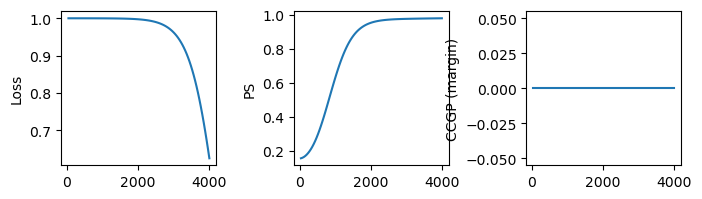

0.9783387780189514


In [163]:
# within class correlation
epsilon = 1e-3
input_size =  40
hidden_size = 400
output_size = 2
lr = 0.01
wd = 0.02
num_element = 4
r = 1

iden = torch.eye(num_element, dtype = torch.float32)
cin = iden - 1/num_element
Uin, Sin, Vint = np.linalg.svd(cin)
U = np.concatenate((np.ones((1, num_element))/np.sqrt(num_element), Vint[:num_element-1,:]), axis=0)

#np.random.seed(3)  #bad example for purely random C
#np.random.seed(1)  #good example for purely random C; and commutative C
#np.random.seed(2) #bad example for commutative C

np.random.seed(24)
sigma_x0 = np.random.randn(num_element)
sigma_x = sigma_x0*r
#m =  ortho_group.rvs(dim = num_element).astype(np.float32) 
#X0 = np.matmul(np.diag(sigma_x), m) 
X0 = np.matmul(np.diag(sigma_x), U.astype(np.float32))
C = np.matmul(X0.T, X0) 
print(sigma_x[0]/sigma_x[1], sigma_x[0]/sigma_x[2], sigma_x[0]/sigma_x[3])


num_epochs = 4000

X_train = torch.zeros((num_element*(2**output_size), input_size), dtype = torch.float32)
y_train0 = torch.tensor([[1,1],[1,-1],[-1,1],[-1,-1]],dtype = torch.float32)
y_train = torch.zeros((num_element*(2**output_size), output_size), dtype = torch.float32)

for i in range(2**output_size):
    #C = np.eye(num_element) - c/num_element #clist[i]/num_element
    U, S, V = np.linalg.svd(C)
    X_train0 = torch.tensor(np.matmul(np.diag(np.sqrt(S)), V), dtype = torch.float32)
    X_train1 = torch.zeros((input_size, num_element))
    X_train1[i*num_element:(i+1)*num_element, :] = X_train0
    X_train[i*num_element:(i+1)*num_element] = X_train1.T
    y_train[i*num_element:(i+1)*num_element] = torch.outer(y_train0[i], torch.ones( num_element,)).T


epoch_num, loss1_list, ps1_list, ccgp1_list, pr1_list, pc1_list, s1_list, h1_list = train_twolayerNN(X_train, y_train, input_size, hidden_size, output_size, epsilon, epsilon, lr, num_epochs, 1,wd,0)
ThreePlot(epoch_num, loss1_list, ps1_list, ccgp1_list)
print(ps1_list[-1])

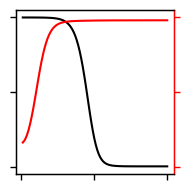

In [250]:
fig, ax1 = plt.subplots(figsize=(2, 2))

# Plot on the left y‐axis
ax1.plot(epoch_num, loss1_list, 'k-')
ax1.set_xlabel('')
ax1.set_ylabel('')

ax1.set_xticks([0, 2000, 4000])
ax1.set_xticklabels(['','',''])
ax1.set_yticks([0, 0.5, 1])
ax1.set_yticklabels(['','',''])
ax1.tick_params(axis='x', width=1, length=4)
ax1.tick_params(axis='y', width=1, length=4)
ax1.set(ylim=(-0.05, 1.05))


for spine in ['left','bottom', 'top']:
    ax1.spines[spine].set_linewidth(1)

# Create second axes that shares the same x‐axis
ax2 = ax1.twinx()
# Plot on the right y‐axis
ax2.plot(epoch_num,  ps1_list, 'r-')
ax2.set_ylabel('')
ax2.tick_params(axis='y', colors='r',width=1, length=4)
ax2.set_yticks([0, 0.5, 1])
ax2.set_yticklabels(['','',''])
ax2.spines['right'].set_color('r')
ax2.spines['right'].set_linewidth(1)
ax2.set(ylim=(-0.05, 1.05))



fig.align_ylabels([ax1, ax2])
# Save the figure to disk
plt.savefig('Loss_epochs_multielemnt.eps', dpi=300)
plt.tight_layout()
plt.show()

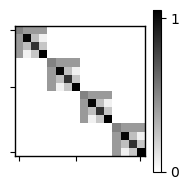

In [173]:
p = X_train.size(0)
c = np.sum(C)/num_element
Cx = np.matmul(X_train.numpy(), X_train.numpy().T)
Ch0 = np.matmul(h1_list[-1].T, h1_list[-1]) 
Cy = np.matmul(y_train.numpy(), y_train.numpy().T) + output_size
ck = np.trace(np.matmul(Ch0, Cy))/np.linalg.norm(Ch0)/np.linalg.norm(Cy)
coeff = np.linalg.norm(Ch0)/np.linalg.norm(Cy)/np.sqrt((input_size+c)*c/input_size/(input_size + 2*c)) 

fig, ax = plt.subplots(figsize=(2, 2))
im = ax.imshow(Cx, cmap='binary', vmin=0, vmax=np.max(Cx))
ax.set_xticks([0, 7, 15])
ax.set_xticklabels(['','',''])
ax.set_yticks([0, 7, 15])
ax.set_yticklabels(['','',''])

for spine in ['left','bottom', 'top', 'right']:
    ax.spines[spine].set_linewidth(1)
    
# Create colorbar with ticks at -2, 0, +2
cbar = fig.colorbar(im, ax=ax, ticks=[-1, 0, 1])
cbar.set_label('')



plt.savefig('Cx_inclass.eps', dpi=300)
#plt.savefig('Cx_inclass_colorbar.eps', dpi=300)
plt.tight_layout()
plt.show()
#print(ck, coeff)

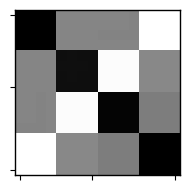

In [177]:
Ch0 = np.matmul(h1_list[-1].T, h1_list[-1]) 
Cy = np.matmul(y_train.numpy(), y_train.numpy().T) + output_size
ck = np.trace(np.matmul(Ch0, Cy))/np.linalg.norm(Ch0)/np.linalg.norm(Cy)
coeff = np.linalg.norm(Ch0)/np.linalg.norm(Cy)/np.sqrt((input_size+c)*c/input_size/(input_size + 2*c)) 

fig, ax = plt.subplots(figsize=(2, 2))
im = ax.imshow(Ch0, cmap='binary', vmax=np.max(Ch0))
ax.set_xticks([0, 7, 15])
ax.set_xticklabels(['','',''])
ax.set_yticks([0, 7, 15])
ax.set_yticklabels(['','',''])

for spine in ['left','bottom', 'top', 'right']:
    ax.spines[spine].set_linewidth(1)
    
# Create colorbar with ticks at -2, 0, +2
#cbar = fig.colorbar(im, ax=ax, ticks=[0, 0.5, 1])
#cbar.set_label('')



plt.savefig('Ch_inclass.eps', dpi=300)
plt.tight_layout()
plt.show()
#print(ck, coeff)

In [324]:
# within class correlation (num_element)
epsilon = 1e-3
input_size =  80
hidden_size = 400
output_size = 2
lr = 0.01
wd = 0.02
r = 1

num_list = [1,2,4,8,16]

ck = np.zeros((len(num_list), ))
coeff = np.zeros((len(num_list), ))


for j in range(len(num_list)):

    num_element = num_list[j]
    
    iden = torch.eye(num_element, dtype = torch.float32)
    cin = iden - 1/num_element
    Uin, Sin, Vint = np.linalg.svd(cin)
    U = np.concatenate((np.ones((1, num_element))/np.sqrt(num_element), Vint[:num_element-1,:]), axis = 0)
    
    np.random.seed(24)
    sigma_x0 = np.random.randn(num_element)
    sigma_x = np.abs(sigma_x0*r)
    X0 = np.matmul(np.diag(np.sort(sigma_x)[::-1]), U.astype(np.float32))
    C = np.matmul(X0.T, X0) 
    
    num_epochs = 10000
    
    X_train = torch.zeros((num_element*(2**output_size), input_size), dtype = torch.float32)
    y_train0 = torch.tensor([[1,1],[1,-1],[-1,1],[-1,-1]],dtype = torch.float32)
    y_train = torch.zeros((num_element*(2**output_size), output_size), dtype = torch.float32)
    
    
    
    for i in range(2**output_size):
        U, S, V = np.linalg.svd(C)
        X_train0 = torch.tensor(np.matmul(np.diag(np.sqrt(S)), V), dtype = torch.float32)
        X_train1 = torch.zeros((input_size, num_element))
        X_train1[i*num_element:(i+1)*num_element, :] = X_train0
        X_train[i*num_element:(i+1)*num_element] = X_train1.T
        y_train[i*num_element:(i+1)*num_element] = torch.outer(y_train0[i], torch.ones(num_element,)).T
    
    
    epoch_num, loss1_list, ps1_list, ccgp1_list, pr1_list, pc1_list, s1_list, h1_list = train_twolayerNN(X_train, y_train, input_size, hidden_size, output_size, epsilon, epsilon, lr, num_epochs, 1,wd,0)
    #ThreePlot(epoch_num, loss1_list, ps1_list, ccgp1_list)
    #print(ps1_list[-1])
    
    Cy = np.matmul(y_train.numpy(), y_train.numpy().T) + output_size
    p = X_train.size(0)
    c = np.sum(C)/num_element
    Ch0 = np.matmul(h1_list[-1].T, h1_list[-1]) 
    ck[j] = np.trace(np.matmul(Ch0, Cy))/np.linalg.norm(Ch0)/np.linalg.norm(Cy)
    coeff[j] = np.linalg.norm(Ch0)/np.linalg.norm(Cy)/np.sqrt((input_size+c)*c/input_size/(input_size + 2*c)) 
    print(ck[j], coeff[j])

Epoch [1/10000], Loss: 1.0000
Epoch [2500/10000], Loss: 0.0012
Epoch [5000/10000], Loss: 0.0012
Epoch [7500/10000], Loss: 0.0012
Epoch [10000/10000], Loss: 0.0012
0.9997712439543799 3.79451505263302
Epoch [1/10000], Loss: 1.0000
Epoch [2500/10000], Loss: 0.0022
Epoch [5000/10000], Loss: 0.0022
Epoch [7500/10000], Loss: 0.0022
Epoch [10000/10000], Loss: 0.0022
0.9995376516727301 2.8875212877088097
Epoch [1/10000], Loss: 1.0000
Epoch [2500/10000], Loss: 0.0095
Epoch [5000/10000], Loss: 0.0041
Epoch [7500/10000], Loss: 0.0041
Epoch [10000/10000], Loss: 0.0041
0.996512564866678 2.267076100143492
Epoch [1/10000], Loss: 1.0000
Epoch [2500/10000], Loss: 0.4302
Epoch [5000/10000], Loss: 0.0067
Epoch [7500/10000], Loss: 0.0067
Epoch [10000/10000], Loss: 0.0067
0.9925779128698833 1.720806729502013
Epoch [1/10000], Loss: 1.0000
Epoch [2500/10000], Loss: 0.6696
Epoch [5000/10000], Loss: 0.0077
Epoch [7500/10000], Loss: 0.0077
Epoch [10000/10000], Loss: 0.0077
0.9908626551151771 1.2554731874516847


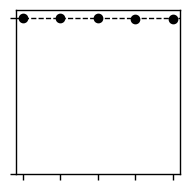

In [327]:
# plot
filename = f'Alignment_withinClass.npz'
folder_path = os.path.join(os.getcwd(), filename)
np.savez(folder_path, ck = ck, coeff = coeff)


fig, ax = plt.subplots(1, 1, figsize=(2, 2))

ax.scatter(np.log2(num_list), ck, color = 'k')
ax.axhline(y = 1, color='k', linestyle='--', linewidth=1)
ax.set_xticks([0,1,2,3,4])
ax.set_xticklabels(['','','','',''])
ax.set_yticks([0, 1])
ax.set_yticklabels(['',''])
ax.tick_params(axis='x', width=1, length=4)
ax.tick_params(axis='y', width=1, length=4)
ax.set(ylim=(0, 1.05))


for spine in ['left','bottom', 'top', 'right']:
    ax.spines[spine].set_linewidth(1)

#plt.legend()
plt.savefig('TheoryvsSim_WithinClass.eps', dpi=300)
plt.tight_layout()
plt.show()

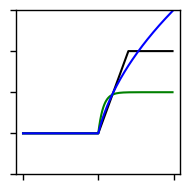

In [1672]:
# Try three nonlinearity

hardsig_fun = nn.Hardsigmoid()
class CustomActivation(nn.Module):
    def __init__(self):
        super(CustomActivation, self).__init__()
    
    def forward(self, x):
        return torch.where(x < 0, torch.zeros_like(x), 1-torch.exp(-x))

class SqrtActivation(nn.Module):
    def __init__(self):
        super(SqrtActivation, self).__init__()
    
    def forward(self, x):
        return torch.where(x < 0, torch.zeros_like(x), torch.sqrt(x+1) - 1)

exp_fun = CustomActivation()
sqrt_fun = SqrtActivation()


x = torch.from_numpy(np.arange(-15, 15, 0.2))
y1 = 2*hardsig_fun(x-3)
y2 = exp_fun(x)
y3 = sqrt_fun(x)

fig, ax = plt.subplots(1, 1, figsize=(2, 2))

ax.plot(x, y1, color = 'k')
ax.plot(x, y2, color = 'g')
ax.plot(x, y3, color = 'b')

ax.set_xticks([-15, 0, 15])
ax.set_xticklabels(['','',''])
ax.set_yticks([-1, 0, 1, 2, 3])
ax.set_yticklabels(['','','','',''])
ax.tick_params(axis='x', width=1, length=4)
ax.tick_params(axis='y', width=1, length=4)
ax.set(ylim=(-1, 3))


for spine in ['left','bottom', 'top', 'right']:
    ax.spines[spine].set_linewidth(1)

plt.savefig('Nonlinear.eps', dpi=300)
plt.tight_layout()
plt.show()

Epoch [1/12000], Loss: 1.0000
Epoch [3000/12000], Loss: 1.0000
Epoch [6000/12000], Loss: 0.9696
Epoch [9000/12000], Loss: 0.0226
Epoch [12000/12000], Loss: 0.0174


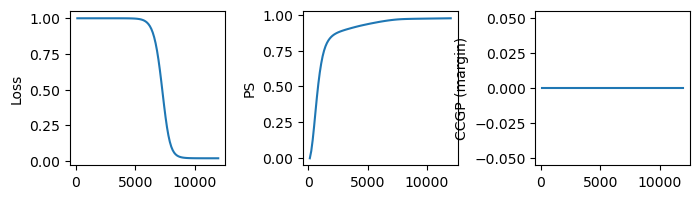

0.976450502872467
Epoch [1/12000], Loss: 1.0000
Epoch [3000/12000], Loss: 0.0027
Epoch [6000/12000], Loss: 0.0024
Epoch [9000/12000], Loss: 0.0024
Epoch [12000/12000], Loss: 0.0024


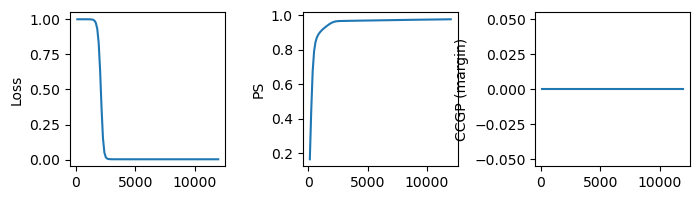

0.9770744442939758
Epoch [1/12000], Loss: 1.0000
Epoch [3000/12000], Loss: 0.9986
Epoch [6000/12000], Loss: 0.0107
Epoch [9000/12000], Loss: 0.0089
Epoch [12000/12000], Loss: 0.0089


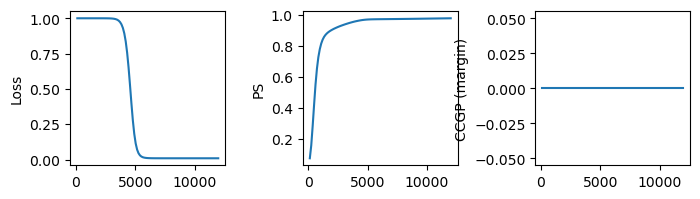

0.9770744442939758


In [567]:
# whitened inputs for three nonlinearity

import itertools

epsilon = 2e-5
hidden_size = 400
output_size = 2
input_size =  40
lr = 0.01
wd = 0.02


num_epochs = 12000

X_train0 = torch.eye(2**output_size, dtype = torch.float32)
X_train = torch.cat((X_train0, torch.zeros(X_train0.size(0), input_size - X_train0.size(1))), dim = 1)

y_train = 2*(torch.tensor(list(itertools.product([0, 1], repeat = output_size)))-1/2)


epoch_num, loss1_list, ps1_list, ccgp1_list, pr1_list, pc1_list, s1_list, h1_list = train_twolayerNN_Hardsig(X_train, y_train, input_size, hidden_size, output_size, epsilon, epsilon, lr, num_epochs, 1,wd,0)
ThreePlot(epoch_num, loss1_list, ps1_list, ccgp1_list)
print(ps1_list[-1])

epoch_num, loss2_list, ps2_list, ccgp2_list, pr2_list, pc2_list, s2_list, h2_list = train_twolayerNN_Exp(X_train, y_train, input_size, hidden_size, output_size, epsilon, epsilon, lr, num_epochs, 1,wd,0)
ThreePlot(epoch_num, loss2_list, ps2_list, ccgp2_list)
print(ps2_list[-1])

epoch_num, loss3_list, ps3_list, ccgp3_list, pr3_list, pc3_list, s3_list, h3_list = train_twolayerNN_Sqrt(X_train, y_train, input_size, hidden_size, output_size, epsilon, epsilon, lr, num_epochs, 1,wd,0)
ThreePlot(epoch_num, loss3_list, ps3_list, ccgp3_list)
print(ps2_list[-1])

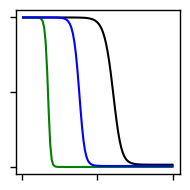

In [573]:
fig, ax = plt.subplots(1, 1, figsize=(2, 2))

ax.plot(epoch_num, loss1_list, color = 'k')
ax.plot(epoch_num, loss2_list, color = 'g')
ax.plot(epoch_num, loss3_list, color = 'b')

ax.set_xticks([0, 6000, 12000])
ax.set_xticklabels(['','',''])
ax.set_yticks([0, 0.5, 1])
ax.set_yticklabels(['','',''])
ax.tick_params(axis='x', width=1, length=4)
ax.tick_params(axis='y', width=1, length=4)
#ax.set(ylim=(0, 1))


for spine in ['left','bottom', 'top', 'right']:
    ax.spines[spine].set_linewidth(1)

plt.savefig('Loss_nonlinearity.eps', dpi=300)
plt.tight_layout()
plt.show()

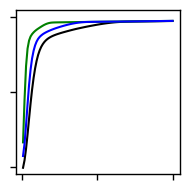

In [575]:
fig, ax = plt.subplots(1, 1, figsize=(2, 2))

ax.plot(epoch_num, ps1_list, color = 'k')
ax.plot(epoch_num, ps2_list, color = 'g')
ax.plot(epoch_num, ps3_list, color = 'b')

ax.set_xticks([0, 6000, 12000])
ax.set_xticklabels(['','',''])
ax.set_yticks([0, 0.5, 1])
ax.set_yticklabels(['','',''])
ax.tick_params(axis='x', width=1, length=4)
ax.tick_params(axis='y', width=1, length=4)
ax.set(ylim=(-0.05, 1.05))

for spine in ['left','bottom', 'top', 'right']:
    ax.spines[spine].set_linewidth(1)

plt.savefig('PS_nonlinearity.eps', dpi=300)
plt.tight_layout()
plt.show()

In [593]:
# PS vs Cxy for commutative perturbation (Other nonlinearity)

import itertools

eps = [1e-3,1e-3,1e-3]
input_size =  10
hidden_size = 700
output_size = 3
lr = 0.03
wd = 0.02


num_repeat = 50
r11 = 0

nonlinear = ['Hardsigmoid', 'expontial','Sqrt']

xy_align_tot = np.zeros(( 9*num_repeat, len(nonlinear)))
ps_tot = np.zeros(( 9*num_repeat, len(nonlinear)))

for k in range(len(nonlinear)):
    epsilon = eps[k]
    nf = nonlinear[k]
    filename = f'Yortho_{nf}_{r11}_TwoLayer_{wd}_Sysinitial_{epsilon}_inputsize_{input_size}_outputsize_{output_size}_lr_{lr}_numlist.npz'
    folder_path = os.path.join(os.getcwd(), filename)
    a = np.load(folder_path)
    num_list = a['num_list']
    
    y_train = 2*(torch.tensor(list(itertools.product([0, 1], repeat = output_size)))-1/2)
    xy_align = np.zeros((num_repeat, len(num_list)-1, 2))
    ps_stats = np.zeros((num_repeat, len(num_list)-1))
    perf_stats = np.zeros((num_repeat, len(num_list)-1))
    
    for i in range(len(num_list)-1):
        for j in range(num_list[i]):
            filename = f'Two-Layer Scan\Yortho_{nf}_{r11}_cvalue_{i+1}_TwoLayer_{wd}_Sysinitial_{epsilon}_inputsize_{input_size}_outputsize_{output_size}_lr_{lr}_repeat_{j}.npz'
            folder_path = os.path.join(os.getcwd(), filename)
            data = np.load(folder_path)
            X_train = data['X_train']
            X_train1 =  np.concatenate((X_train, np.ones((X_train.shape[0], 1))), axis = 1)
            loss1_list = data['loss1_list']
            ps1_list = data['ps1_list']
        
            # compute histogram
            ps_stats[j, i] = np.mean(ps1_list[-5:])
            perf_stats[j, i] = np.mean(loss1_list[-5:])
    
            # compute alignment
            cx = np.matmul(X_train, X_train.T)
            cy = np.matmul(y_train, y_train.T)
            xy_align[j, i, 0] = np.trace(np.matmul(cx, cy))/np.trace(cx)/np.trace(cy)*output_size
            xy_align[j, i, 1] =np.trace(cx)**2/np.linalg.norm(cx)**2
    
    idx = (perf_stats[:,:] <= 0.1)
    num_element = np.count_nonzero(idx)
    xy_align_tot[:num_element, k] = xy_align[idx, 0].flatten()
    ps_tot[:num_element, k] = ps_stats[idx].flatten()

0.375


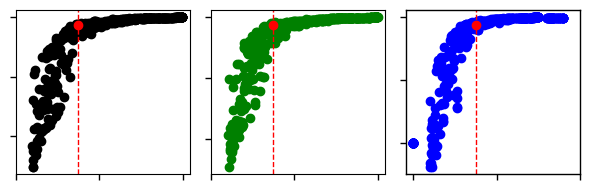

In [609]:
ch0 = np.trace(np.matmul(np.eye(y_train.shape[0]), cy))/np.trace(np.eye(y_train.shape[0]))/np.trace(cy)*output_size
print(ch0)

color_list = ['k', 'g', 'b']

fig, ax = plt.subplots(1, 3, figsize=(6, 2))
for k in range(3):

    ax[k].scatter(xy_align_tot[:, k], ps_tot[:, k], color = color_list[k])
    ax[k].scatter([ch0], [0.94], color = 'r')
    ax[k].axvline(x=ch0, color='r', linestyle='--', linewidth=1)
    ax[k].set_xticks([0, 0.5, 1])
    ax[k].set_xticklabels(['','',''])
    ax[k].set_yticks([0, 0.5, 1])
    ax[k].set_yticklabels(['','',''])
    ax[k].tick_params(axis='x', width=1, length=4)
    ax[k].tick_params(axis='y', width=1, length=4)
    #ax[k].set_xlim([0, 1.05])
    #ax[k].set_ylim([-0.2, 1.05])

for spine in ['left','bottom', 'top', 'right']:
    ax[k].spines[spine].set_linewidth(1)


fig.subplots_adjust(wspace=0.5)

plt.tight_layout()
plt.savefig('CxyPS_nonlinearity.eps', dpi=300)
plt.show()

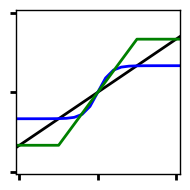

In [1221]:
# 2nd class nonlinearity (3 examples)

hardtanh_fun = nn.Hardtanh()
tanh_fun = nn.Tanh()

x = torch.from_numpy(np.arange(-3, 3, 0.2))
y1 = x
y2 = tanh_fun(3*x)
y3 = 2*hardtanh_fun(x)

fig, ax = plt.subplots(1, 1, figsize=(2, 2))

ax.plot(x, y1, color = 'k', linewidth = 2)
ax.plot(x, y2, color = 'b', linewidth = 2)
ax.plot(x, y3, color = 'g', linewidth = 2)

ax.set_xticks([-2, 0, 2])
ax.set_xticklabels(['','',''])
ax.set_yticks([-3, 0, 3])
ax.set_yticklabels(['','',''])
ax.tick_params(axis='x', width=2, length=4)
ax.tick_params(axis='y', width=2, length=4)
ax.set(xlim=(-2.1, 2.1))
ax.set(ylim=(-3.1, 3.1))


for spine in ['left','bottom', 'top', 'right']:
    ax.spines[spine].set_linewidth(1)

plt.savefig('Nonlinear_2nd.eps', dpi=300)
plt.tight_layout()
plt.show()

Epoch [1/7000], Loss: 1.0000


C:\Users\binw9\AppData\Local\Temp\ipykernel_34012\1000778365.py:52: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3679.)
  biasl = torch.mm(torch.unsqueeze(b1.T,1),torch.ones(1, X_train.size(0)))


Epoch [1750/7000], Loss: 0.6407
Epoch [3500/7000], Loss: 0.0016
Epoch [5250/7000], Loss: 0.0016
Epoch [7000/7000], Loss: 0.0016


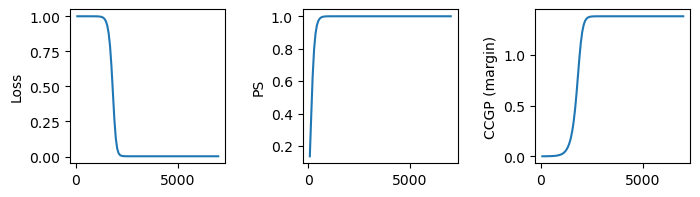

1.0000000596046448
Epoch [1/7000], Loss: 1.0000
Epoch [1750/7000], Loss: 0.0004
Epoch [3500/7000], Loss: 0.0004
Epoch [5250/7000], Loss: 0.0004
Epoch [7000/7000], Loss: 0.0004


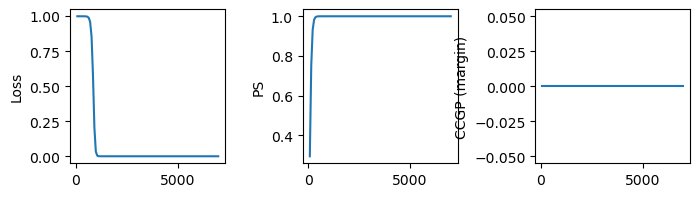

0.9999999403953552
Epoch [1/7000], Loss: 1.0000
Epoch [1750/7000], Loss: 0.9570
Epoch [3500/7000], Loss: 0.0004
Epoch [5250/7000], Loss: 0.0004
Epoch [7000/7000], Loss: 0.0004


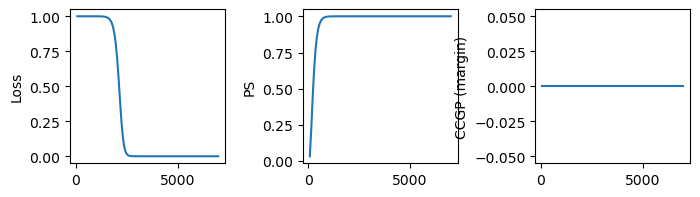

0.9999999403953552


In [32]:
# whitened inputs for three nonlinearity (2nd) 

#%run TwoLayerNN.ipynb
import itertools

epsilon = 2e-5
hidden_size = 400
output_size = 2
input_size =  4
lr = 0.01
wd = 0.02


num_epochs = 7000

X_train0 = torch.eye(2**output_size, dtype = torch.float32)
X_train = torch.cat((X_train0, torch.zeros(X_train0.size(0), input_size - X_train0.size(1))), dim = 1)

y_train = 2*(torch.tensor(list(itertools.product([0, 1], repeat = output_size)))-1/2)


epoch_num, loss1_list, ps1_list, ccgp1_list, pr1_list, pc1_list, s1_list, h1_list = train_twolayerNN_linear(X_train, y_train, input_size, hidden_size, output_size, epsilon, epsilon, lr, num_epochs, 1,wd,0)
ThreePlot(epoch_num, loss1_list, ps1_list, ccgp1_list)
print(ps1_list[-1])

epoch_num, loss2_list, ps2_list, ccgp2_list, pr2_list, pc2_list, s2_list, h2_list = train_twolayerNN_Tanh(X_train, y_train, input_size, hidden_size, output_size, epsilon, epsilon, lr, num_epochs, 1,wd,0)
ThreePlot(epoch_num, loss2_list, ps2_list, ccgp2_list)
print(ps2_list[-1])

epoch_num, loss3_list, ps3_list, ccgp3_list, pr3_list, pc3_list, s3_list, h3_list = train_twolayerNN_Hardtanh(X_train, y_train, input_size, hidden_size, output_size, epsilon, epsilon, lr/2.5, num_epochs, 1,wd,0)
ThreePlot(epoch_num, loss3_list, ps3_list, ccgp3_list)
print(ps2_list[-1])

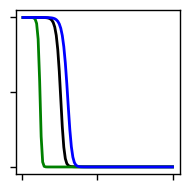

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(2, 2))

ax.plot(epoch_num, loss1_list, color = 'k', linewidth = 2)
ax.plot(epoch_num, loss2_list, color = 'g', linewidth = 2)
ax.plot(epoch_num, loss3_list, color = 'b', linewidth = 2)

ax.set_xticks([0, 3500, 7000])
ax.set_xticklabels(['','',''])
ax.set_yticks([0, 0.5, 1])
ax.set_yticklabels(['','',''])
ax.tick_params(axis='x', width=1, length=4)
ax.tick_params(axis='y', width=1, length=4)
#ax.set(ylim=(0, 1))


for spine in ['left','bottom', 'top', 'right']:
    ax.spines[spine].set_linewidth(1)

plt.savefig('Loss_nonlinearity_2nd.eps', dpi=300)
plt.tight_layout()
plt.show()

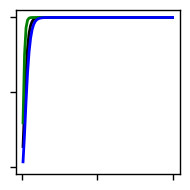

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(2, 2))

ax.plot(epoch_num, ps1_list, color = 'k', linewidth = 2)
ax.plot(epoch_num, ps2_list, color = 'g', linewidth = 2)
ax.plot(epoch_num, ps3_list, color = 'b', linewidth = 2)

ax.set_xticks([0, 3500, 7000])
ax.set_xticklabels(['','',''])
ax.set_yticks([0, 0.5, 1])
ax.set_yticklabels(['','',''])
ax.tick_params(axis='x', width=1, length=4)
ax.tick_params(axis='y', width=1, length=4)
ax.set(ylim=(-0.05, 1.05))

for spine in ['left','bottom', 'top', 'right']:
    ax.spines[spine].set_linewidth(1)

plt.savefig('PS_nonlinearity_2nd.eps', dpi=300)
plt.tight_layout()
plt.show()

In [85]:
# Modularity analysis: 1st/2nd class nonlinearity
%run TwoLayerNN.ipynb

epsilon = 1e-4
input_size =  4
hidden_size = 400
output_size = 2
lr = 0.01
wd = 0.03
rho = 0
noise = 0

num_epochs = 40000

m = np.eye(input_size)
X_train0 = torch.tensor([[1, rho, rho, rho], [rho, 1, rho, rho], [rho, rho, 1, rho], [rho, rho, rho, 1]],dtype = torch.float32)
X_train1 = torch.cat((X_train0, torch.zeros(X_train0.size(0), input_size - X_train0.size(1))), dim = 1)
X_train2 = torch.mm(torch.from_numpy(m.astype(np.float32)), X_train1.T).T
X_train = torch.cat((X_train2, torch.ones((X_train2.size(0), 1), dtype = torch.float32)), axis = 1)

y_train = torch.tensor([[1,1],[1,-1],[-1,1],[-1,-1]],dtype = torch.float32)

epoch_num, loss1_list, ps1_list, ccgp1_list, pr1_list, pc1_list, s1_list, h1_list, w1_list1, w2_list1 = train_twolayerNN_MuPW12(X_train, y_train, input_size+1, hidden_size, output_size, epsilon*np.sqrt(hidden_size/X_train0.size(1)), epsilon, lr, num_epochs, 1,wd,noise)
#ThreePlot(epoch_num, loss1_list, ps1_list, ccgp1_list)
#print(ps1_list[-1])
#PCAplot(pc1_list, s1_list[-1])

#print(np.matmul(h1_list[-1].T, h1_list[-1]))
#print(np.matmul(y_train, y_train.T))

Epoch [1/40000], Loss: 1.0000
Epoch [4444/40000], Loss: 0.0230
Epoch [8888/40000], Loss: 0.0201
Epoch [13332/40000], Loss: 0.0199
Epoch [17776/40000], Loss: 0.0198
Epoch [22220/40000], Loss: 0.0198
Epoch [26664/40000], Loss: 0.0197
Epoch [31108/40000], Loss: 0.0197
Epoch [35552/40000], Loss: 0.0196
Epoch [39996/40000], Loss: 0.0196


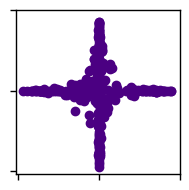

In [86]:
w2 = w2_list1[-1]

fig, ax = plt.subplots(1, 1, figsize=(2, 2))

ax.scatter(w2[0,:], w2[1,:], color = 'indigo')
ax.set_xticks([-0.3, 0, 0.3])
ax.set_xticklabels(['','',''])
ax.set_yticks([-0.3, 0, 0.3])
ax.set_yticklabels(['','',''])
ax.tick_params(axis='x', width=1, length=4)
ax.tick_params(axis='y', width=1, length=4)

for spine in ['left','bottom', 'top', 'right']:
    ax.spines[spine].set_linewidth(1)

plt.gca().set_aspect('equal')
plt.savefig('W2_cluster_sqrt.eps', dpi=300)
plt.tight_layout()
plt.show()

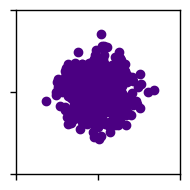

In [45]:
w2 = w2_list1[-1]

fig, ax = plt.subplots(1, 1, figsize=(2, 2))

ax.scatter(w2[0,:], w2[1,:], color = 'indigo')
ax.set_xticks([-0.3, 0, 0.3])
ax.set_xticklabels(['','',''])
ax.set_yticks([-0.3, 0, 0.3])
ax.set_yticklabels(['','',''])
ax.tick_params(axis='x', width=1, length=4)
ax.tick_params(axis='y', width=1, length=4)

for spine in ['left','bottom', 'top', 'right']:
    ax.spines[spine].set_linewidth(1)

plt.gca().set_aspect('equal')
plt.savefig('W2_cluster_tanh.eps', dpi=300)
plt.tight_layout()
plt.show()

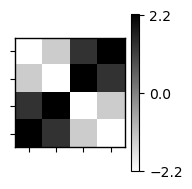

In [220]:
y_train = torch.tensor([[2,1],[2,-1],[-2,1],[-2,-1]], dtype = torch.float32)/1.5
Cy = np.matmul(y_train.numpy(), y_train.numpy().T) 

fig, ax = plt.subplots(figsize=(2, 2))
im = ax.imshow(-Cy, cmap='binary', vmin=np.min(Cy), vmax=np.max(Cy))
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['','','',''])
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(['','','',''])

for spine in ['left','bottom', 'top', 'right']:
    ax.spines[spine].set_linewidth(1)
    
# Create colorbar with ticks at -2, 0, +2
cbar = fig.colorbar(im, ax=ax, ticks=[-2.2,0, 2.2])
cbar.set_label('')


plt.savefig('Cy_anisotropy.eps', dpi=300)
plt.tight_layout()
plt.show()

Epoch [1/5000], Loss: 1.1111
Epoch [1250/5000], Loss: 0.4380
Epoch [2500/5000], Loss: 0.1934
Epoch [3750/5000], Loss: 0.0265
Epoch [5000/5000], Loss: 0.0228


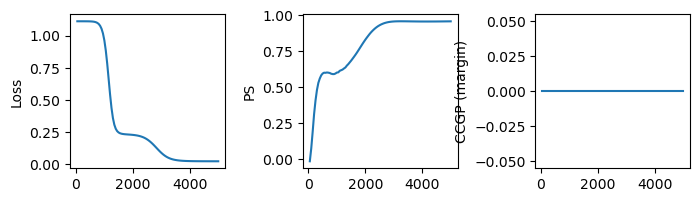

0.9573700726032257


In [242]:
epsilon = 1e-3
hidden_size = 100
output_size = 2
input_size =  2**output_size
lr = 0.02
wd = 0.03

num_epochs = 5000

X_train0 = torch.eye(2**output_size, dtype = torch.float32)
X_train = torch.cat((X_train0, torch.zeros(X_train0.size(0), input_size - X_train0.size(1))), dim = 1)


epoch_num, loss1_list, ps1_list, ccgp1_list, pr1_list, pc1_list, s1_list, h1_list = train_twolayerNN(X_train, y_train, input_size, hidden_size, output_size, epsilon, epsilon, lr, num_epochs, 1,wd,0)
ThreePlot(epoch_num, loss1_list, ps1_list, ccgp1_list)
print(ps1_list[-1])

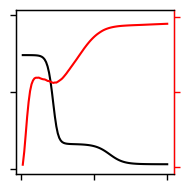

In [1387]:
# loss/PS vs. time

# Create figure and first axes
fig, ax1 = plt.subplots(figsize=(2, 2))

# Plot on the left y‐axis
ax1.plot(epoch_num, loss1_list, 'k-')
ax1.set_xlabel('')
ax1.set_ylabel('')

ax1.set_xticks([0, 2500, 5000])
ax1.set_xticklabels(['','',''])
ax1.set_yticks([0, 0.75, 1.5])
ax1.set_yticklabels(['','',''])
ax1.tick_params(axis='x', width=1, length=4)
ax1.tick_params(axis='y', width=1, length=4)
ax1.set(ylim=(-0.05, 1.55))


for spine in ['left','bottom', 'top']:
    ax1.spines[spine].set_linewidth(1)

# Create second axes that shares the same x‐axis
ax2 = ax1.twinx()
# Plot on the right y‐axis
ax2.plot(epoch_num,  ps1_list, 'r-')
ax2.set_ylabel('')
ax2.tick_params(axis='y', colors='r',width=1, length=4)
ax2.set_yticks([0, 0.5, 1])
ax2.set_yticklabels(['','',''])
ax2.spines['right'].set_color('r')
ax2.spines['right'].set_linewidth(1)
ax2.set(ylim=(-0.05, 1.05))


fig.align_ylabels([ax1, ax2])
# Save the figure to disk
plt.savefig('Loss_epochs_aniso.eps', dpi=300)
plt.tight_layout()
plt.show()

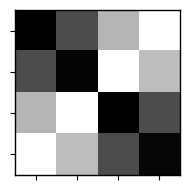

In [1205]:
# Hidden representation
Ch0 = np.matmul(h1_list[-1].T, h1_list[-1]) 


fig, ax = plt.subplots(figsize=(2, 2))
im = ax.imshow(Ch0, cmap='binary')
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['','','',''])
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(['','','',''])

for spine in ['left','bottom', 'top', 'right']:
    ax.spines[spine].set_linewidth(1)
    
# Create colorbar with ticks at -2, 0, +2
#cbar = fig.colorbar(im, ax=ax, ticks=[0, 0.5, 1])
#cbar.set_label('')



plt.savefig('Ch_aniso.eps', dpi=300)
plt.tight_layout()
plt.show()

Epoch [1/80000], Loss: 1.0000
Epoch [20000/80000], Loss: 0.9993
Epoch [40000/80000], Loss: 0.6002
Epoch [60000/80000], Loss: 0.0000
Epoch [80000/80000], Loss: 0.0000


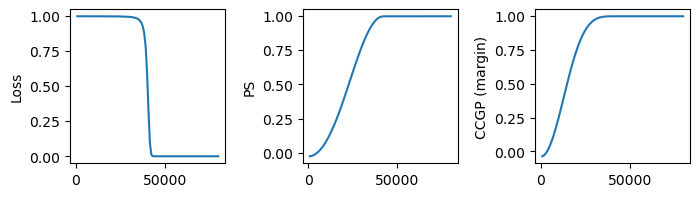

In [1424]:
# N-layer MuP with mean-field limit:
import itertools
#%run TwoLayerNN.ipynb
 
epsilon = 1e-1
input_size =  20
hidden_size = 400
output_size = 2
lr = 0.4
wd = 0.001/hidden_size

num_epochs = 80000

X_train0 = torch.tensor([[1,0,0,0], [0,1,0,0], [0,0,1,0], [0,0,0,1]],dtype = torch.float32)*1
#X_train0 = torch.randn(2**output_size, input_size)/np.sqrt(input_size)
X_train1 = torch.cat((X_train0, torch.zeros(X_train0.size(0), input_size - X_train0.size(1))), dim = 1)
X_train_free = torch.cat((X_train1, torch.zeros((X_train1.size(0), 1), dtype = torch.float32)), axis = 1)
X_train_bias = torch.cat((X_train1, torch.ones((X_train1.size(0), 1), dtype = torch.float32)), axis = 1)
y_train = 2*(torch.tensor(list(itertools.product([0, 1], repeat = output_size)))-1/2)

#print(np.matmul(X_train_free, X_train_free.T))
#print(np.matmul(X_train_bias, X_train_bias.T))

epoch_num, loss_list, ps_list, ccgp_list, h_list, h2_list = train_NlayerNN_MuP_meanfield(X_train_bias, y_train, input_size+1, hidden_size, output_size, epsilon, epsilon, lr, num_epochs, 1,wd,0)
ThreePlot(epoch_num, loss_list, ps_list[:,0], ps_list[:,1])

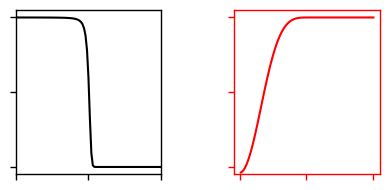

In [1430]:
fig, ax = plt.subplots(1, 2, figsize=(4, 2))

# Plot on the left y‐axis
ax[0].plot(epoch_num, loss_list, 'k-')
ax[0].set_xlabel('')
ax[0].set_ylabel('')

ax[0].set_xticks([0, 40000, 80000])
ax[0].set_xticklabels(['','',''])
ax[0].set_yticks([0, 0.5, 1])
ax[0].set_yticklabels(['','',''])
ax[0].tick_params(axis='x', width=1, length=4)
ax[0].tick_params(axis='y', width=1, length=4)
ax[0].set(ylim=(-0.05, 1.05))
ax[0].set(xlim=(0, 80000))



# Create second axes that shares the same x‐axis
#ax2 = ax1.twinx()
# Plot on the right y‐axis
ax[1].plot(epoch_num,  ps_list[:,1], 'r-')
ax[1].set_ylabel('')
ax[1].tick_params(axis='x', width=1, length=4, colors='r')
ax[1].tick_params(axis='y', width=1, length=4, colors='r')
ax[1].set_xticks([0, 40000, 80000])
ax[1].set_xticklabels(['','',''])
ax[1].set_yticks([0, 0.5, 1])
ax[1].set_yticklabels(['','',''])
#ax[1].spines['right'].set_color('r')
#ax[1].spines['right'].set_linewidth(1)
ax[1].set(ylim=(-0.05, 1.05))

for spine in ['left','right','bottom', 'top']:
    ax[0].spines[spine].set_linewidth(1)
    ax[1].spines[spine].set_linewidth(1)
    ax[1].spines[spine].set_color('r')
    ax[1].spines[spine].set_linewidth(1)

#fig.align_ylabels([ax1, ax2])
# Save the figure to disk
plt.savefig('Loss_epochs_DNNs.eps', dpi=300)
plt.tight_layout()
plt.subplots_adjust(wspace = 0.5)
plt.show()

In [1282]:
class CustomRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, sig_h, epsilon1):
        super(CustomRNN, self).__init__()
        self.hidden_size = hidden_size
        self.sig_h = sig_h
        self.alpha = 0.1
        # Define weight layers:
        # W_ih: input to hidden transformation
        # W_hh: hidden to hidden transformation
        self.W_ih = nn.Linear(input_size, hidden_size, bias = True)
        self.W_hh = nn.Linear(hidden_size, hidden_size, bias = False)
        
        # Define the output layer
        self.fc = nn.Linear(hidden_size, output_size, bias = False)

        nn.init.uniform_(self.W_ih.weight, -epsilon1, epsilon1)
        nn.init.uniform_(self.W_hh.weight, -epsilon1, epsilon1)
        nn.init.uniform_(self.fc.weight, -epsilon1, epsilon1)
        nn.init.uniform_(self.W_ih.bias, -epsilon1, epsilon1)
        
    def forward(self, x):
        """
        x: input tensor of shape (batch_size, input_size)
        """

        h_t = self.W_ih(x)                    # shape: (batch_size, hidden_size)

        # 2) We'll keep all h_t in a list, then stack at the end
        h_list = [h_t]
    
        # 3) Iterate for the remaining steps
        for _ in range(seq_len-1):
            # out-of-place update
            #h_t = self.W_hh(h_t)              # shape: (batch_size, hidden_size)
            h_t = self.W_hh(torch.relu(h_t)) #+ self.sig_h*torch.randn(x.size(0), self.hidden_size)
            #h_t = (1-self.alpha)*ht + self.alpha*(self.W_hh(torch.relu(ht))) + self.sig_h*torch.randn(x.size(0), self.hidden_size)
            h_list.append(h_t)
    
        # 4) Stack them into a (batch, hidden, seq_len) tensor
        h_all = torch.stack(h_list, dim=2)   # no in-place ops!
    
        # 5) The final output comes from the last hidden
        #out = self.fc(h_t)
        out = self.fc(torch.relu(h_t))
        
        return out, h_t, h_all

In [1432]:
output_size = 2
input_size = 2**output_size        # One-dimensional evidence per time step
seq_len = 3

X_train = torch.eye(2**output_size, dtype = torch.float64)
y_train = 2*(torch.tensor(list(itertools.product([0, 1], repeat = output_size)),dtype = torch.float64)-1/2)


hidden_size = 50       # Size of the hidden state (can be adjusted)
wd = 0.02
lr1 = 0.01
sig_h = 0 
epsilon = 0.11

num_epochs = 8000
rec_epoch = 100
epoch_num = np.zeros((rec_epoch+1,))
loss_history = np.zeros((rec_epoch+1, 2))
ps_list = np.zeros((rec_epoch + 1,))

# Instantiate the model, loss, and optimizer for BPTT
criterion = nn.MSELoss()
model = CustomRNN(input_size, hidden_size, output_size, sig_h, epsilon).to(dtype=torch.float64)
optimizer1 = optim.SGD(model.parameters(), lr=lr1, weight_decay = wd)
model.train()

# Training loop
idx_t = 0
for epoch in range(num_epochs):
    # Forward pass
    outputs, _, _ = model(X_train)  # shape: (num_samples, output_size)
    loss = criterion(outputs, y_train)
    
    # Backward and optimize
    optimizer1.zero_grad()
    loss.backward()
    optimizer1.step()
    
    
    if ((epoch+1) % (num_epochs//rec_epoch) == 0) or (epoch == 0):
        epoch_num[idx_t] = epoch
        out, hT, _ = model(X_train)
        accuracy_train  = criterion(out, y_train).item()
        loss_history[idx_t,0] = accuracy_train
        ps_list[idx_t] = ps_highD(hT.detach().numpy(), y_train.numpy())
        idx_t = idx_t + 1    
    if ((epoch+1) % (num_epochs//10) == 0) or (epoch == 0):
        print(f"BPTT:  Epoch [{epoch+1}/{num_epochs}], Loss: {accuracy_train:.4f},  PS: {ps_list[idx_t-1]:.4f}")

BPTT:  Epoch [1/8000], Loss: 1.0012,  PS: -0.0644
BPTT:  Epoch [800/8000], Loss: 0.9942,  PS: 0.3838
BPTT:  Epoch [1600/8000], Loss: 0.9811,  PS: 0.7760
BPTT:  Epoch [2400/8000], Loss: 0.7360,  PS: 0.8612
BPTT:  Epoch [3200/8000], Loss: 0.0243,  PS: 0.9782
BPTT:  Epoch [4000/8000], Loss: 0.0011,  PS: 0.9844
BPTT:  Epoch [4800/8000], Loss: 0.0010,  PS: 0.9889
BPTT:  Epoch [5600/8000], Loss: 0.0011,  PS: 0.9945
BPTT:  Epoch [6400/8000], Loss: 0.0010,  PS: 0.9973
BPTT:  Epoch [7200/8000], Loss: 0.0010,  PS: 0.9986
BPTT:  Epoch [8000/8000], Loss: 0.0010,  PS: 0.9992


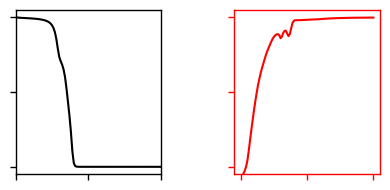

In [1434]:
fig, ax = plt.subplots(1, 2, figsize=(4, 2))

# Plot on the left y‐axis
ax[0].plot(epoch_num, loss_history[:,0], 'k-')
ax[0].set_xlabel('')
ax[0].set_ylabel('')

ax[0].set_xticks([0, 4000, 8000])
ax[0].set_xticklabels(['','',''])
ax[0].set_yticks([0, 0.5, 1])
ax[0].set_yticklabels(['','',''])
ax[0].tick_params(axis='x', width=1, length=4)
ax[0].tick_params(axis='y', width=1, length=4)
ax[0].set(ylim=(-0.05, 1.05))
ax[0].set(xlim=(0, 8000))



# Create second axes that shares the same x‐axis
#ax2 = ax1.twinx()
# Plot on the right y‐axis
ax[1].plot(epoch_num,  ps_list, 'r-')
ax[1].set_ylabel('')
ax[1].tick_params(axis='x', width=1, length=4, colors='r')
ax[1].tick_params(axis='y', width=1, length=4, colors='r')
ax[1].set_xticks([0, 4000, 8000])
ax[1].set_xticklabels(['','',''])
ax[1].set_yticks([0, 0.5, 1])
ax[1].set_yticklabels(['','',''])
#ax[1].spines['left'].set_color('r')
#ax[1].spines['right'].set_linewidth(1)
ax[1].set(ylim=(-0.05, 1.05))

for spine in ['left','right','bottom', 'top']:
    ax[0].spines[spine].set_linewidth(1)
    ax[1].spines[spine].set_linewidth(1)
    ax[1].spines[spine].set_color('r')
    ax[1].spines[spine].set_linewidth(1)


#fig.align_ylabels([ax1, ax2])
# Save the figure to disk
plt.savefig('Loss_epochs_RNNs.eps', dpi=300)
plt.tight_layout()
plt.subplots_adjust(wspace = 0.5)
plt.show()

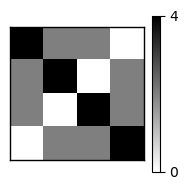

In [12]:
rho = 0
X_train = np.array([[1, rho, rho, rho], [rho, 1, rho, rho], [rho, rho, 1, rho], [rho, rho, rho, 1]])
y_train = np.array([[1,1],[1,-1],[-1,1],[-1,-1]])
Cx = np.matmul(X_train, X_train.T) 
Cy = np.matmul(y_train, y_train.T) + y_train.shape[1]

fig, ax = plt.subplots(figsize=(2, 2))
im = ax.imshow(Cy, cmap='binary', vmax=np.max(Cy))
ax.set_xticks([])
ax.set_yticks([])

for spine in ['left','bottom', 'top', 'right']:
    ax.spines[spine].set_linewidth(1)

cbar = fig.colorbar(im, ax=ax, ticks=[0, 4])
cbar.set_label('')

plt.savefig('Colorbar.eps', dpi=300)
plt.tight_layout()
plt.show()

In [ ]:
# Create colorbar with ticks at -2, 0, +2
